In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

In [3]:
data= xr.load_dataset('../data/train_data/train.zarr')

In [4]:
data

<xarray.Dataset> Size: 7GB
Dimensions:          (vars_aux: 8, lat: 64, lon: 64, time: 14610,
                      vars_level: 4, level: 7)
Coordinates:
  * vars_aux         (vars_aux) <U23 736B 'land_sea_mask' ... 'type_of_high_v...
  * lat              (lat) float64 512B -30.0 -28.5 -27.0 ... 61.5 63.0 64.5
  * lon              (lon) float64 512B 300.0 301.5 303.0 ... 31.5 33.0 34.5
  * time             (time) datetime64[ns] 117kB 1979-01-01 ... 2018-12-31
  * vars_level       (vars_level) <U3 48B 'ta' 'hus' 'ua' 'va'
  * level            (level) int64 56B 1000 850 700 500 250 100 50
Data variables:
    input_auxiliary  (vars_aux, lat, lon) float32 131kB 0.9621 0.9912 ... 3.18
    input_level      (time, vars_level, level, lat, lon) float32 7GB 297.9 .....
    target           (time, lat, lon) float32 239MB 0.4779 0.4137 ... 0.6305

In [8]:
data['input_auxiliary'].sel(vars_aux=i,drop=True)

<xarray.DataArray 'input_auxiliary' (lat: 64, lon: 64)> Size: 16kB
array([[0.962059  , 0.99123   , 0.9809911 , ..., 0.16367884, 0.        ,
        0.        ],
       [0.9803538 , 0.96408707, 0.9808138 , ..., 0.8651787 , 0.09291165,
        0.        ],
       [0.99721503, 0.96762383, 0.93169385, ..., 0.99399596, 0.35399988,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.47294316, 0.8496438 ,
        0.77050745],
       [0.        , 0.        , 0.        , ..., 0.9161322 , 0.8680014 ,
        0.7492486 ],
       [0.        , 0.        , 0.        , ..., 0.877201  , 0.92510426,
        0.75289464]], shape=(64, 64), dtype=float32)
Coordinates:
  * lat      (lat) float64 512B -30.0 -28.5 -27.0 -25.5 ... 60.0 61.5 63.0 64.5
  * lon      (lon) float64 512B 300.0 301.5 303.0 304.5 ... 30.0 31.5 33.0 34.5

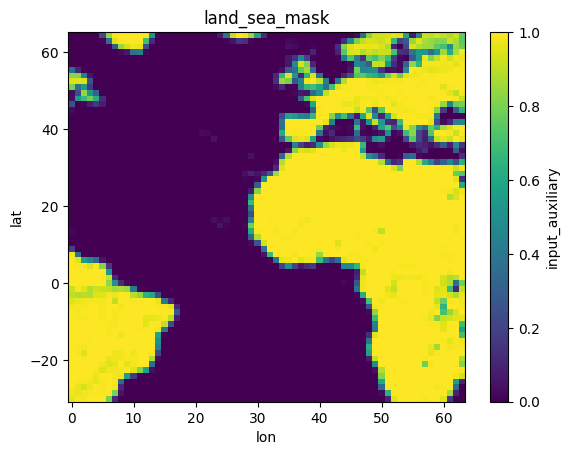

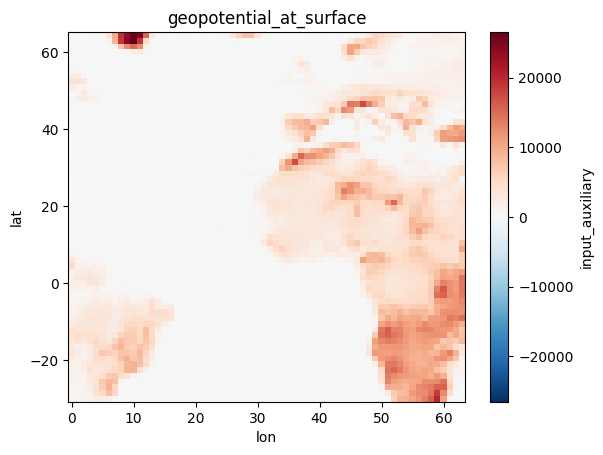

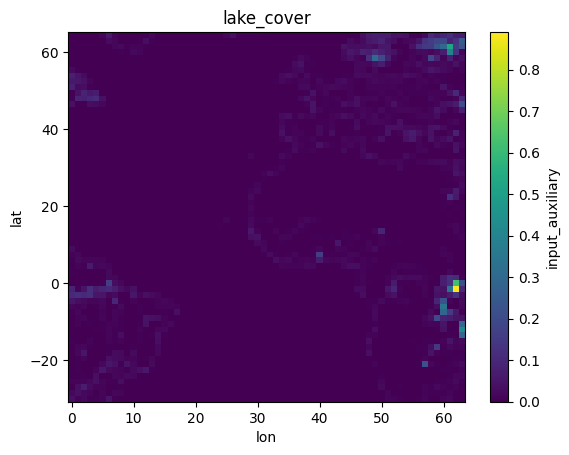

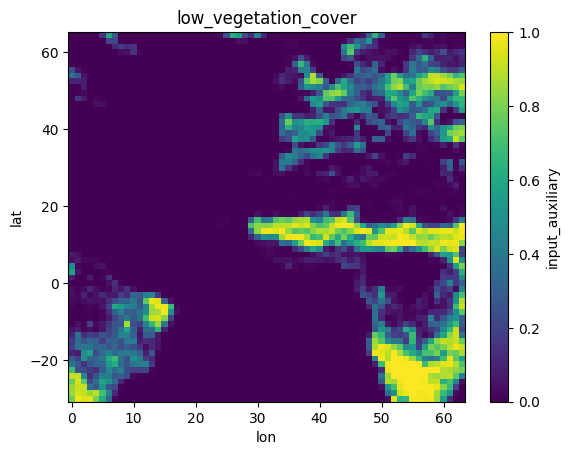

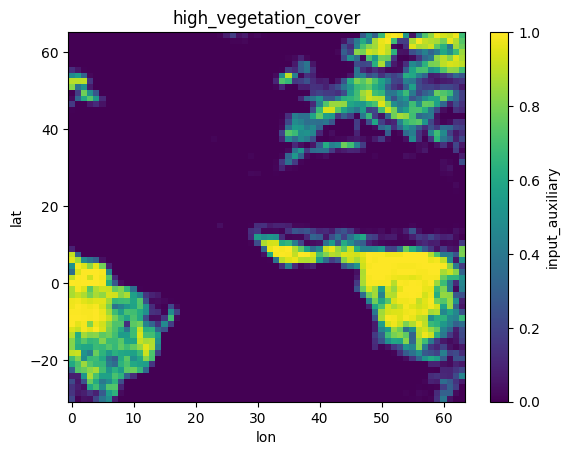

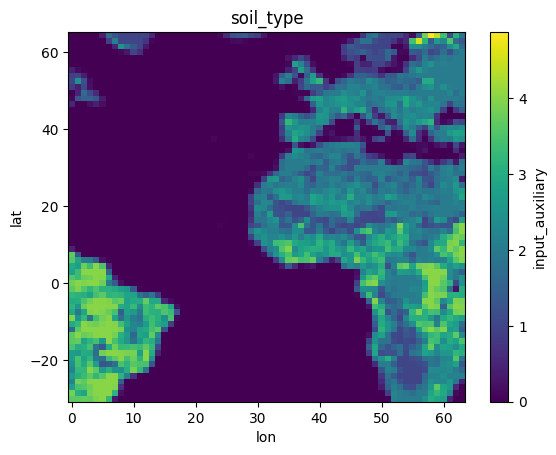

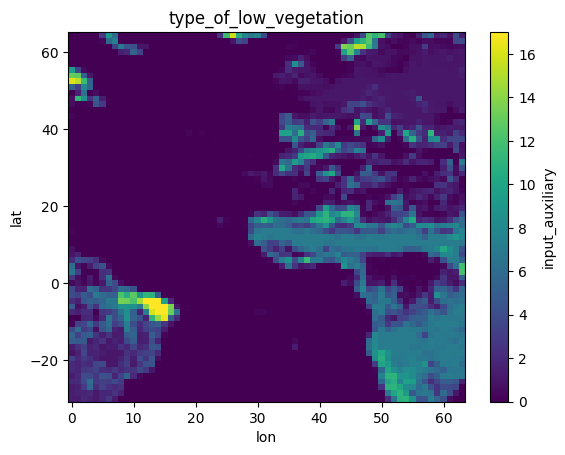

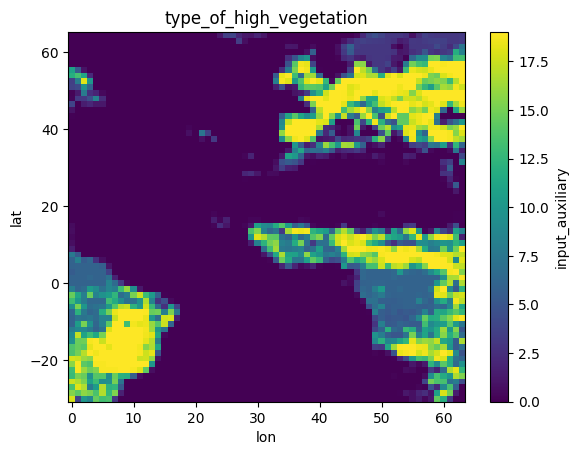

In [16]:
for i in data.vars_aux.values:
    data_i=data['input_auxiliary'].sel(vars_aux=i,drop=True)
    data_i['lon'] = np.arange(len(data_i.lon))#data_i['lon'].where(data_i.lon<180, 360-data_i.lon)
    data_i.sortby(['lat','lon']).plot()
    plt.title(i)
    plt.show()

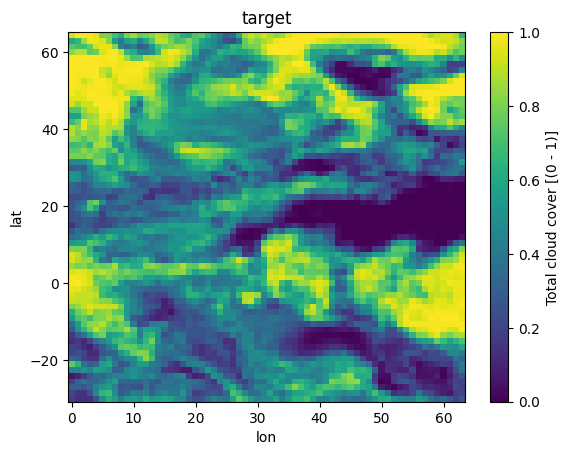

In [23]:
data_i=data['target'].isel(time=100,drop=True)
data_i['lon'] = np.arange(len(data_i.lon))#data_i['lon'].where(data_i.lon<180, 360-data_i.lon)
data_i.sortby(['lat','lon']).plot()
plt.title('target')
plt.show()

(array([3794629., 1022465.,  921642.,  951096., 1067767., 1252311.,
        1469017., 1669804., 1805617., 1888747., 1932297., 1939196.,
        1931850., 1920980., 1913609., 1909527., 1901819., 1906375.,
        1915312., 1930287., 1949676., 1973624., 2020983., 2050298.,
        2092200., 2139352., 2203663., 2348999., 2700592., 5318826.]),
 array([0.        , 0.03333334, 0.06666667, 0.10000001, 0.13333334,
        0.16666667, 0.20000002, 0.23333335, 0.26666668, 0.30000001,
        0.33333334, 0.36666667, 0.40000004, 0.43333337, 0.4666667 ,
        0.5       , 0.53333336, 0.56666672, 0.60000002, 0.63333338,
        0.66666669, 0.70000005, 0.73333335, 0.76666671, 0.80000007,
        0.83333337, 0.86666673, 0.90000004, 0.9333334 , 0.9666667 ,
        1.        ]),
 <BarContainer object of 30 artists>)

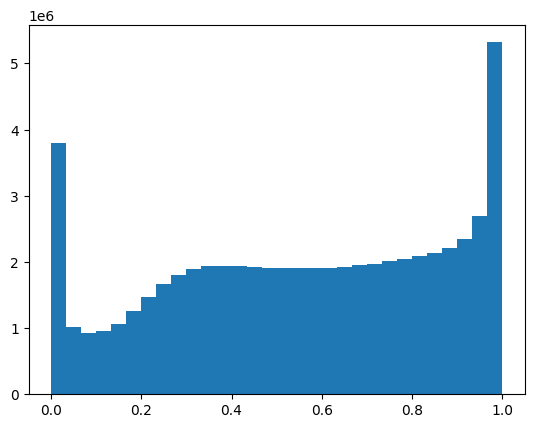

In [25]:
plt.hist(data.target.values.flatten(),bins=30)

# Validation

In [9]:
obs = xr.load_dataset('../data/train_data/val_era5_region1.zarr')['target']
obs['lon'] = np.arange(len(obs.lon))#data_i['lon'].where(data_i.lon<180, 360-data_i.lon)
obs

<xarray.DataArray 'target' (sample: 365, lat: 64, lon: 64)> Size: 6MB
array([[[0.3894099 , 0.8641949 , 0.9692869 , ..., 0.75309855,
         0.8311565 , 0.9394038 ],
        [0.7467885 , 0.9502149 , 0.93323034, ..., 0.8465322 ,
         0.9571707 , 0.99470985],
        [0.90081066, 0.93338954, 0.94362915, ..., 0.9462041 ,
         0.9887191 , 0.98973453],
        ...,
        [0.99993455, 0.97781557, 0.9259366 , ..., 0.99966604,
         0.9999379 , 1.        ],
        [0.9973823 , 0.9631616 , 0.94598055, ..., 0.99962246,
         0.99987745, 1.        ],
        [0.9156034 , 0.9726105 , 0.9268743 , ..., 0.99970067,
         0.99987316, 0.9999409 ]],

       [[0.58976513, 0.76062113, 0.7719901 , ..., 0.92429376,
         0.74088824, 0.67667884],
        [0.64281523, 0.71707726, 0.6859056 , ..., 0.61472046,
         0.61209977, 0.62699646],
        [0.59067106, 0.5119253 , 0.70990425, ..., 0.81225455,
         0.8469026 , 0.9370086 ],
...
        [0.8940469 , 0.9659325 , 0.9367626 , ..., 0.9998728 ,
         0.99999946, 0.9923486 ],
        [0.9244903 , 0.9764769 , 0.8644155 , ..., 0.9860147 ,
         0.99609864, 0.9621651 ],
        [0.89693296, 0.7570881 , 0.7508617 , ..., 0.9713807 ,
         0.95830995, 0.9350443 ]],

       [[0.84728867, 0.9059002 , 0.9180393 , ..., 0.8909156 ,
         0.712953  , 0.48997015],
        [0.85828036, 0.8817362 , 0.87705034, ..., 0.8602013 ,
         0.64678204, 0.41600844],
        [0.86190295, 0.876235  , 0.81787276, ..., 0.916627  ,
         0.7834967 , 0.72244155],
        ...,
        [0.97856086, 0.9917443 , 0.991784  , ..., 0.8558014 ,
         0.9615426 , 0.9734714 ],
        [0.9877386 , 0.982356  , 0.9216711 , ..., 0.734045  ,
         0.76260364, 0.8193648 ],
        [0.9508442 , 0.98336434, 0.9626505 , ..., 0.68860686,
         0.7013153 , 0.72248614]]], shape=(365, 64, 64), dtype=float32)
Coordinates:
  * lat      (lat) float64 512B -30.0 -28.5 -27.0 -25.5 ... 60.0 61.5 63.0 64.5
  * lon      (lon) int64 512B 0 1 2 3 4 5 6 7 8 9 ... 55 56 57 58 59 60 61 62 63
Dimensions without coordinates: sample
Attributes:
    long_name:      Total cloud cover
    short_name:     tcc
    standard_name:  cloud_area_fraction
    units:          (0 - 1)

In [6]:
data = xr.load_dataset('../data/forecasts/experiment_unet/val_era5_region1.nc')
data['lon'] = np.arange(len(data.lon))#data_i['lon'].where(data_i.lon<180, 360-data_i.lon)
data

<xarray.Dataset> Size: 6MB
Dimensions:            (sample: 365, lat: 64, lon: 64)
Coordinates:
  * sample             (sample) int64 3kB 0 1 2 3 4 5 ... 360 361 362 363 364
  * lat                (lat) float64 512B -30.0 -28.5 -27.0 ... 61.5 63.0 64.5
  * lon                (lon) int64 512B 0 1 2 3 4 5 6 7 ... 57 58 59 60 61 62 63
Data variables:
    total_cloud_cover  (sample, lat, lon) float32 6MB 0.8441 0.9275 ... 0.903

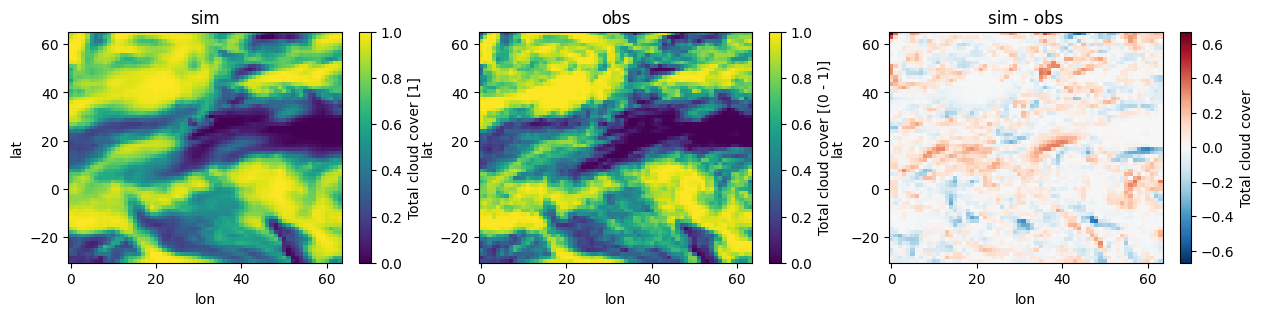

In [19]:
sample=0
sample=100

fig,ax=plt.subplots(1,3,figsize=(15,3))
data['total_cloud_cover'].isel(sample=sample).plot(ax=ax[0])
obs.isel(sample=sample).plot(ax=ax[1])
(data['total_cloud_cover'].isel(sample=sample) - obs.isel(sample=sample)).plot(ax=ax[2])
ax[0].set_title('sim')
ax[1].set_title('obs')
ax[2].set_title('sim - obs')
plt.show()